# Figure 4 (Standalone) - Probe Learning Curves Across Checkpoints

**Self-contained version for Google Colab** — every function this experiment needs (environments, models, replay buffer, DQN loop with checkpointing, plasticity probe with learning-curve logging) is defined inline below; there are no imports from the repository's `src/` package. Upload this single file to Colab and run it.

**Colab setup**: `Runtime → Change runtime type → GPU` (a T4 is plenty). All required libraries (torch, torchvision, numpy, pandas, matplotlib, tqdm) are preinstalled on Colab.

**What it reproduces**: Section 5.3 of Lyle et al., *Understanding Plasticity in Neural Networks*. Figure 3 summarizes plasticity loss as one scalar per checkpoint; this experiment goes deeper by recording the **entire probe-optimization trajectory** for checkpoints saved at different points in DQN training. If plasticity is being lost gradually, later checkpoints fit the same random-target probe more slowly or plateau at a worse final loss — visible directly in the shape of the loss curves.

**Session budgeting**: the paper-like run is a single ~100k-step training plus probes on 4 checkpoints (roughly 30–60 min on a T4 for the MLP). To compare architectures/environments, run one variant per session (edit the dormant paper-scale cell at the bottom) and give each a distinct output tag.

## Setup

Paths are relative to the working directory (`/content` on Colab). Datasets download automatically on first use; results land in `outputs/tables` and `outputs/figures` — download them via Colab's file browser (left sidebar) before the session ends.

In [1]:
import copy
import random
import time
from dataclasses import dataclass, replace
from pathlib import Path
from typing import Dict, List, Optional, Sequence

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from collections import deque

ROOT = Path.cwd()
DATA_ROOT = ROOT / "data"
OUTPUT_ROOT = ROOT / "outputs"
FIGURES_DIR = OUTPUT_ROOT / "figures"
TABLES_DIR = OUTPUT_ROOT / "tables"
for directory in (DATA_ROOT, OUTPUT_ROOT, FIGURES_DIR, TABLES_DIR):
    directory.mkdir(parents=True, exist_ok=True)


def _default_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():  # Apple-silicon GPU
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = _default_device()
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla T4


## Environments: the Classification MDPs (paper Section 3.2)

MNIST/CIFAR-10 classification recast as a ten-state, ten-action block MDP. A latent state selects a class-conditional image observation; the agent predicts an action in `{0..9}`; the reward rule defines the variant: **easy** (true labels), **hard** (random labels), **sparse** (reward only at state 9 → action 9).

In [2]:
@dataclass(frozen=True)
class ClassificationMDPSpec:
    name: str
    num_states: int = 10
    num_actions: int = 10


class ClassificationMDP:
    def __init__(self, dataset, spec, labels=None, seed=None):
        self.dataset = dataset
        self.spec = spec
        self.rng = random.Random(seed)
        self.labels = labels if labels is not None else self._true_labels(dataset)
        self.class_indices = self._build_class_indices(self.labels)
        self.state = self.rng.randrange(self.spec.num_states)

    @staticmethod
    def _true_labels(dataset):
        targets = getattr(dataset, "targets", None)
        if targets is None:
            return [int(dataset[idx][1]) for idx in range(len(dataset))]
        if isinstance(targets, torch.Tensor):
            return [int(value) for value in targets.tolist()]
        return [int(value) for value in targets]

    def _build_class_indices(self, labels):
        class_indices = {state: [] for state in range(self.spec.num_states)}
        for idx, raw_label in enumerate(labels):
            label = int(raw_label)
            if 0 <= label < self.spec.num_states:
                class_indices[label].append(idx)
        empty = [state for state, indices in class_indices.items() if not indices]
        if empty:
            raise ValueError(f"Every MDP state must have at least one image. Missing states: {empty}")
        return class_indices

    def reset(self, state=None):
        self.state = self.rng.randrange(self.spec.num_states) if state is None else int(state)
        return self.sample_observation(self.state)

    def sample_observation(self, state=None):
        state = self.state if state is None else int(state)
        idx = self.rng.choice(self.class_indices[state])
        image, _ = self.dataset[idx]
        return image

    def transition(self, action):
        raise NotImplementedError

    def step(self, action):
        reward, next_state = self.transition(int(action))
        self.state = int(next_state)
        return self.sample_observation(self.state), float(reward), self.state


def make_random_labels(dataset, num_states=10, seed=None):
    rng = random.Random(seed)
    return [rng.randrange(num_states) for _ in range(len(dataset))]


class EasyMDP(ClassificationMDP):
    def __init__(self, dataset, seed=None):
        super().__init__(dataset, ClassificationMDPSpec(name="easy"), seed=seed)

    def transition(self, action):
        reward = float(int(action) == int(self.state))
        self.state = self.rng.randrange(self.spec.num_states)
        return reward, self.state


class HardMDP(ClassificationMDP):
    def __init__(self, dataset, seed=None):
        labels = make_random_labels(dataset, seed=seed)
        super().__init__(dataset, ClassificationMDPSpec(name="hard"), labels=labels, seed=seed)

    def transition(self, action):
        reward = float(int(action) == int(self.state))
        self.state = self.rng.randrange(self.spec.num_states)
        return reward, self.state


class SparseMDP(ClassificationMDP):
    def __init__(self, dataset, seed=None):
        super().__init__(dataset, ClassificationMDPSpec(name="sparse"), seed=seed)

    def transition(self, action):
        action_matches_state = int(action) == int(self.state)
        reward = float(action_matches_state and int(self.state) == 9)
        if action_matches_state:
            next_state = (int(self.state) + 1) % self.spec.num_states
        else:
            next_state = self.rng.randrange(self.spec.num_states)
        self.state = next_state
        return reward, next_state

## Models (paper Appendix A.2)

In [3]:
def _prod(values):
    out = 1
    for v in values:
        out *= int(v)
    return out


def _maybe_spectral_norm(module, enabled):
    return nn.utils.spectral_norm(module) if enabled else module


class MLP(nn.Module):
    def __init__(self, input_shape=(1, 28, 28), num_actions=10, hidden_dim=512,
                 use_layernorm=False, spectral_norm=False):
        super().__init__()
        self.input_dim = _prod(input_shape)
        self.hidden_dim = int(hidden_dim)
        self.num_actions = int(num_actions)
        self.feature_dim = self.hidden_dim

        self.fc1 = _maybe_spectral_norm(nn.Linear(self.input_dim, self.hidden_dim), spectral_norm)
        self.fc2 = _maybe_spectral_norm(nn.Linear(self.hidden_dim, self.hidden_dim), spectral_norm)
        self.output = nn.Linear(self.hidden_dim, self.num_actions)

        self.ln1 = nn.LayerNorm(self.hidden_dim) if use_layernorm else nn.Identity()
        self.ln2 = nn.LayerNorm(self.hidden_dim) if use_layernorm else nn.Identity()
        self.relu1 = nn.ReLU()
        self.relu2 = nn.ReLU()

    def forward_features(self, x):
        x = x.view(x.size(0), -1)
        x = self.relu1(self.ln1(self.fc1(x)))
        x = self.relu2(self.ln2(self.fc2(x)))
        return x

    def forward(self, x):
        return self.output(self.forward_features(x))


class CNN(nn.Module):
    def __init__(self, input_shape=(1, 28, 28), num_actions=10, conv_channels=64,
                 fc_dim=256, use_layernorm=False, spectral_norm=False):
        super().__init__()
        input_channels = int(input_shape[0])
        self.input_shape = tuple(int(v) for v in input_shape)
        self.num_actions = int(num_actions)
        self.conv_channels = int(conv_channels)
        self.fc_dim = int(fc_dim)
        self.feature_dim = self.fc_dim

        self.conv1 = _maybe_spectral_norm(nn.Conv2d(input_channels, self.conv_channels, kernel_size=5), spectral_norm)
        self.conv2 = _maybe_spectral_norm(nn.Conv2d(self.conv_channels, self.conv_channels, kernel_size=3), spectral_norm)
        self.relu1 = nn.ReLU()
        self.relu2 = nn.ReLU()
        self.flatten = nn.Flatten()

        with torch.no_grad():
            dummy = torch.zeros(1, *self.input_shape)
            conv1_shape = self.conv1(dummy).shape[1:]
            conv2_shape = self.conv2(self.relu1(self.conv1(dummy))).shape[1:]
            conv_dim = int(torch.numel(torch.zeros(conv2_shape)))

        self.ln1 = nn.LayerNorm(conv1_shape) if use_layernorm else nn.Identity()
        self.ln2 = nn.LayerNorm(conv2_shape) if use_layernorm else nn.Identity()

        self.fc1 = _maybe_spectral_norm(nn.Linear(conv_dim, self.fc_dim), spectral_norm)
        self.fc2 = _maybe_spectral_norm(nn.Linear(self.fc_dim, self.fc_dim), spectral_norm)
        self.output = nn.Linear(self.fc_dim, self.num_actions)

        self.ln3 = nn.LayerNorm(self.fc_dim) if use_layernorm else nn.Identity()
        self.ln4 = nn.LayerNorm(self.fc_dim) if use_layernorm else nn.Identity()
        self.relu3 = nn.ReLU()
        self.relu4 = nn.ReLU()

    def forward_features(self, x):
        x = self.relu1(self.ln1(self.conv1(x)))
        x = self.relu2(self.ln2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.ln3(self.fc1(x)))
        x = self.relu4(self.ln4(self.fc2(x)))
        return x

    def forward(self, x):
        return self.output(self.forward_features(x))

## Replay Buffer

In [4]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.buffer = deque(maxlen=capacity)
        self.device = DEVICE

    def push(self, image, action, reward, next_image):
        self.buffer.append((image, action, reward, next_image))

    def sample(self, batch_size, device=None):
        device = self.device if device is None else device
        batch = random.sample(self.buffer, batch_size)
        images, actions, rewards, next_images = zip(*batch)
        return (
            torch.tensor(np.array(images), dtype=torch.float32, device=device),
            torch.tensor(actions, dtype=torch.long, device=device),
            torch.tensor(rewards, dtype=torch.float32, device=device),
            torch.tensor(np.array(next_images), dtype=torch.float32, device=device),
        )

    def sample_states(self, batch_size, device=None):
        device = self.device if device is None else device
        batch = random.sample(self.buffer, min(batch_size, len(self.buffer)))
        images = [item[0] for item in batch]
        return torch.tensor(np.array(images), dtype=torch.float32, device=device)

    def __len__(self):
        return len(self.buffer)

## DQN Training Loop with Checkpointing

`run_dqn_training` trains end-to-end and snapshots a CPU clone of the model at every step listed in `checkpoint_steps` (step 0 = initialization). The checkpoints are what get probed afterwards. (The repository version also supports periodic interventions and metric callbacks used by other figures; those are omitted here since this experiment doesn't use them.)

In [5]:
@dataclass
class ClassificationDQNConfig:
    seed: int = 0
    data_root: str = "./data"
    download: bool = True
    observation_space: str = "mnist"
    environment: str = "easy"
    architecture: str = "mlp"
    hidden_dim: int = 512
    cnn_channels: int = 64
    cnn_fc_dim: int = 256
    gamma: float = 0.99
    lr: float = 1e-3
    optimizer: str = "adam"
    weight_decay: float = 0.0
    batch_size: int = 512
    replay_capacity: int = 10_000
    warmup_steps: int = 2_000
    train_steps: int = 20_000
    target_update_period: int = 1_000
    epsilon_start: float = 1.0
    epsilon_final: float = 0.1
    epsilon_decay: int = 10_000
    use_layernorm: bool = False
    spectral_norm: bool = False


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def load_dataset(config):
    if config.observation_space == "mnist":
        dataset = datasets.MNIST(root=str(config.data_root), train=True,
                                 download=config.download, transform=transforms.ToTensor())
        input_shape = (1, 28, 28)
    elif config.observation_space == "cifar10":
        dataset = datasets.CIFAR10(root=str(config.data_root), train=True,
                                   download=config.download, transform=transforms.ToTensor())
        input_shape = (3, 32, 32)
    else:
        raise ValueError(f"Unknown observation space: {config.observation_space}")
    return dataset, input_shape


def build_environment(config, dataset):
    if config.environment == "easy":
        return EasyMDP(dataset, seed=config.seed)
    if config.environment == "hard":
        return HardMDP(dataset, seed=config.seed)
    if config.environment == "sparse":
        return SparseMDP(dataset, seed=config.seed)
    raise ValueError(f"Unknown environment: {config.environment}")


def build_model_factory(config, input_shape):
    def factory():
        if config.architecture == "mlp":
            return MLP(input_shape=input_shape, num_actions=10, hidden_dim=config.hidden_dim,
                       use_layernorm=config.use_layernorm, spectral_norm=config.spectral_norm)
        if config.architecture == "cnn":
            return CNN(input_shape=input_shape, num_actions=10, conv_channels=config.cnn_channels,
                       fc_dim=config.cnn_fc_dim, use_layernorm=config.use_layernorm,
                       spectral_norm=config.spectral_norm)
        raise ValueError(f"Unknown architecture: {config.architecture}")
    return factory


def build_optimizer(config, model):
    if config.optimizer == "adam":
        return torch.optim.Adam(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
    if config.optimizer == "sgd":
        return torch.optim.SGD(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
    raise ValueError(f"Unknown optimizer: {config.optimizer}")


def optimizer_factory_from_config(config):
    def factory(model):
        return build_optimizer(config, model)
    return factory


def epsilon_at_step(config, step):
    return config.epsilon_final + (config.epsilon_start - config.epsilon_final) * np.exp(
        -float(step) / float(config.epsilon_decay)
    )


@torch.no_grad()
def select_action(model, observation, epsilon, device=None):
    device = DEVICE if device is None else device
    if random.random() < epsilon:
        return random.randrange(10)
    q_values = model(observation.unsqueeze(0).to(device))
    return int(q_values.argmax(dim=1).item())


def collect_transition(env, model, replay, epsilon, device=None):
    observation = env.sample_observation()
    action = select_action(model, observation, epsilon, device=device)
    next_observation, reward, _ = env.step(action)
    replay.push(observation, action, reward, next_observation)


def dqn_loss(model, target_model, batch, gamma):
    states, actions, rewards, next_states = batch
    q_sa = model(states).gather(1, actions.unsqueeze(1)).squeeze(1)
    with torch.no_grad():
        next_q = target_model(next_states).max(dim=1).values
        target = rewards + gamma * next_q
    return F.mse_loss(q_sa, target)


def train_dqn_step(model, target_model, optimizer, replay, config, device=None):
    device = DEVICE if device is None else device
    batch = replay.sample(config.batch_size, device=device)
    loss = dqn_loss(model, target_model, batch, config.gamma)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    return float(loss.detach().cpu().item())


def clone_for_checkpoint(model, device="cpu"):
    checkpoint = copy.deepcopy(model).to(device)
    checkpoint.eval()
    return checkpoint


def run_dqn_training(config, checkpoint_steps=(), device=None):
    device = DEVICE if device is None else device
    set_seed(config.seed)
    dataset, input_shape = load_dataset(config)
    env = build_environment(config, dataset)
    model_factory = build_model_factory(config, input_shape)
    model = model_factory().to(device)
    initial_model = clone_for_checkpoint(model, device=device)
    target_model = copy.deepcopy(model).to(device)
    optimizer = build_optimizer(config, model)
    replay = ReplayBuffer(config.replay_capacity)

    for _ in tqdm(range(config.warmup_steps), desc="warmup", unit="step", leave=False):
        collect_transition(env, model, replay, epsilon=1.0, device=device)

    checkpoint_set = set(int(step) for step in checkpoint_steps)
    checkpoints = {}
    if 0 in checkpoint_set:
        checkpoints[0] = clone_for_checkpoint(model)
        print("checkpoint saved @ step 0 (initialization)")

    last_loss = float("nan")
    train_bar = tqdm(range(1, config.train_steps + 1), desc="train", unit="step")
    for step in train_bar:
        epsilon = epsilon_at_step(config, step)
        collect_transition(env, model, replay, epsilon=epsilon, device=device)
        last_loss = train_dqn_step(model, target_model, optimizer, replay, config, device=device)

        if step % 100 == 0:
            train_bar.set_postfix(loss=f"{last_loss:.4f}", eps=f"{epsilon:.2f}")

        if step % config.target_update_period == 0:
            target_model.load_state_dict(model.state_dict())

        if step in checkpoint_set:
            checkpoints[step] = clone_for_checkpoint(model)
            print(f"checkpoint saved @ step {step} (loss={last_loss:.4f})")
    train_bar.close()

    return {
        "config": config,
        "model": model,
        "initial_model": initial_model,
        "model_factory": model_factory,
        "replay": replay,
        "checkpoints": checkpoints,
        "last_loss": last_loss,
    }

## Plasticity Probe with Learning-Curve Logging (paper Sections 2.2 / 3.1)

Same random-target probe as figure 3, but here `log_every` records the full-batch loss along the probe optimization so the entire trajectory can be plotted — that trajectory *is* figure 4.

In [6]:
@dataclass
class PlasticityProbeConfig:
    steps: int = 500
    num_tasks: int = 10
    batch_size: Optional[int] = None
    target_scale: float = 1e5
    log_every: Optional[int] = None


@dataclass
class ProbeTaskResult:
    initial_loss: float
    final_loss: float
    learning_curve: List[Dict[str, float]]


def _device_of(model):
    return next(model.parameters()).device


def _sample_indices(inputs, batch_size):
    if batch_size is None or batch_size >= inputs.size(0):
        return None
    return torch.randint(0, inputs.size(0), (batch_size,), device=inputs.device)


@torch.no_grad()
def make_random_function_targets(model, random_model, inputs, target_scale=1e5):
    model.eval()
    random_model.eval()
    inputs = inputs.to(_device_of(model))
    random_model = random_model.to(inputs.device)
    offset = model(inputs).mean(dim=0, keepdim=True)
    random_outputs = random_model(inputs)
    return (offset + torch.sin(target_scale * random_outputs)).detach()


def train_probe_task(model, inputs, targets, optimizer_factory, config, progress_desc=None):
    probe_model = copy.deepcopy(model).to(_device_of(model))
    inputs = inputs.to(_device_of(probe_model))
    targets = targets.to(_device_of(probe_model))
    optimizer = optimizer_factory(probe_model)
    learning_curve = []

    with torch.no_grad():
        initial_loss = float(F.mse_loss(probe_model(inputs), targets).cpu().item())

    if config.log_every is not None:
        learning_curve.append({"step": 0.0, "loss": initial_loss})

    probe_model.train()
    step_iter = tqdm(range(1, config.steps + 1), desc=progress_desc, unit="step",
                     leave=False, disable=progress_desc is None)
    for step in step_iter:
        indices = _sample_indices(inputs, config.batch_size)
        if indices is None:
            batch_inputs, batch_targets = inputs, targets
        else:
            batch_inputs = inputs.index_select(0, indices)
            batch_targets = targets.index_select(0, indices)

        loss = F.mse_loss(probe_model(batch_inputs), batch_targets)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        if progress_desc is not None and step % 50 == 0:
            step_iter.set_postfix(loss=f"{float(loss.detach().cpu()):.4f}")

        if config.log_every is not None and step % config.log_every == 0:
            with torch.no_grad():
                full_loss = F.mse_loss(probe_model(inputs), targets)
            learning_curve.append({"step": float(step), "loss": float(full_loss.cpu().item())})

    with torch.no_grad():
        final_loss = float(F.mse_loss(probe_model(inputs), targets).cpu().item())

    if config.log_every is not None and (
        not learning_curve or learning_curve[-1]["step"] != float(config.steps)
    ):
        learning_curve.append({"step": float(config.steps), "loss": final_loss})

    return ProbeTaskResult(initial_loss=initial_loss, final_loss=final_loss,
                           learning_curve=learning_curve)


def run_random_probe_task(model, random_model_factory, inputs, optimizer_factory, config, progress_desc=None):
    random_model = random_model_factory().to(_device_of(model))
    targets = make_random_function_targets(model, random_model, inputs, target_scale=config.target_scale)
    return train_probe_task(model, inputs, targets, optimizer_factory, config, progress_desc=progress_desc)


def estimate_probe_loss(model, random_model_factory, inputs, optimizer_factory, config, desc=None):
    return [
        run_random_probe_task(
            model, random_model_factory, inputs, optimizer_factory, config,
            progress_desc=None if desc is None else f"{desc} [task {task + 1}/{config.num_tasks}]",
        )
        for task in range(config.num_tasks)
    ]


def probe_learning_curves(checkpoints, random_model_factory, inputs, optimizer_factory, config):
    if config.log_every is None:
        raise ValueError("Set PlasticityProbeConfig.log_every to record learning curves.")
    rows = []
    for checkpoint_name, model in checkpoints.items():
        task_results = estimate_probe_loss(
            model, random_model_factory, inputs, optimizer_factory, config,
            desc=f"probe {checkpoint_name}",
        )
        for task_id, result in enumerate(task_results):
            for point in result.learning_curve:
                rows.append({
                    "checkpoint": checkpoint_name,
                    "task_id": float(task_id),
                    "step": point["step"],
                    "loss": point["loss"],
                    "final_loss": result.final_loss,
                })
    return rows

## Figure 4 Experiment: Train, Checkpoint, and Probe

`run_checkpoint_curve_experiment` trains one DQN agent (snapshotting at `checkpoint_steps`), samples one probe batch from the final replay buffer, then runs the random-target probe on every checkpoint against that same batch — logging the loss every `curve_log_every` probe steps so the full optimization trajectory is recorded.

In [7]:
@dataclass
class CheckpointCurveConfig(ClassificationDQNConfig):
    checkpoint_steps: Sequence[int] = (0, 5_000, 20_000)
    probe_steps: int = 2_000
    num_probe_tasks: int = 10
    probe_batch_size: int = 512
    curve_log_every: int = 50


def with_checkpoint_steps(config, checkpoint_steps):
    return replace(config, checkpoint_steps=tuple(checkpoint_steps))


def run_checkpoint_curve_experiment(config, save_path=None):
    experiment_start = time.perf_counter()
    training = run_dqn_training(config, checkpoint_steps=config.checkpoint_steps, device=DEVICE)
    replay = training["replay"]
    model_factory = training["model_factory"]
    checkpoints = {
        f"step_{step}": model.to(DEVICE) for step, model in training["checkpoints"].items()
    }
    inputs = replay.sample_states(config.probe_batch_size, device=DEVICE)
    probe_config = PlasticityProbeConfig(
        steps=config.probe_steps,
        num_tasks=config.num_probe_tasks,
        batch_size=config.probe_batch_size,
        log_every=config.curve_log_every,
    )
    rows = probe_learning_curves(
        checkpoints, model_factory, inputs, optimizer_factory_from_config(config), probe_config,
    )
    df = pd.DataFrame(rows)
    df.insert(0, "architecture", config.architecture)
    df.insert(0, "environment", config.environment)
    df.insert(0, "observation_space", config.observation_space)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(save_path, index=False)
        print(f"Saved checkpoint probe curves to {save_path}")
    print(f"experiment finished in {(time.perf_counter() - experiment_start) / 60:.1f} min")
    return df

## Configurations

`make_smoke_config` runs in a couple of minutes (sanity check). `make_paper_like_config` matches the paper's scale: 100,000 training steps with checkpoints at 0 / 5k / 20k / 100k.

In [8]:
def make_smoke_config(data_root="./data", download=True):
    return CheckpointCurveConfig(
        data_root=data_root, download=download,
        observation_space="mnist", environment="easy", architecture="mlp",
        hidden_dim=128, batch_size=128, replay_capacity=5_000, warmup_steps=512,
        train_steps=1_000, target_update_period=250,
        checkpoint_steps=(0, 500, 1_000),
        probe_steps=100, num_probe_tasks=2, probe_batch_size=128, curve_log_every=10,
    )


def make_paper_like_config(data_root="./data", download=True, architecture="mlp", environment="easy"):
    return CheckpointCurveConfig(
        data_root=data_root, download=download,
        observation_space="mnist", environment=environment, architecture=architecture,
        hidden_dim=512, train_steps=100_000, target_update_period=1_000,
        checkpoint_steps=(0, 10_000, 20_000, 50_000, 100_000),
        probe_steps=2_000, num_probe_tasks=10, probe_batch_size=512, curve_log_every=1,
    )

## Smoke Run (fast sanity check)

In [9]:
smoke_cfg = make_smoke_config(data_root=str(DATA_ROOT))
curves = run_checkpoint_curve_experiment(smoke_cfg, save_path=TABLES_DIR / "figure4_smoke.csv")
curves.head()

100%|██████████| 9.91M/9.91M [00:00<00:00, 47.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.81MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 12.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.47MB/s]


warmup:   0%|          | 0/512 [00:00<?, ?step/s]

checkpoint saved @ step 0 (initialization)


train:   0%|          | 0/1000 [00:00<?, ?step/s]

checkpoint saved @ step 500 (loss=0.0071)
checkpoint saved @ step 1000 (loss=0.0145)


...

probe step_500 [task 2/2]:   0%|          | 0/100 [00:00<?, ?step/s]

probe step_1000 [task 1/2]:   0%|          | 0/100 [00:00<?, ?step/s]

probe step_1000 [task 2/2]:   0%|          | 0/100 [00:00<?, ?step/s]

Saved checkpoint probe curves to /kaggle/working/outputs/tables/figure4_smoke.csv
experiment finished in 0.1 min


,observation_space,environment,architecture,checkpoint,task_id,step,loss,final_loss
0,mnist,easy,mlp,step_0,0.0,0.0,0.498875,0.000431
1,mnist,easy,mlp,step_0,0.0,10.0,0.405383,0.000431
2,mnist,easy,mlp,step_0,0.0,20.0,0.281997,0.000431
3,mnist,easy,mlp,step_0,0.0,30.0,0.165412,0.000431
4,mnist,easy,mlp,step_0,0.0,40.0,0.081966,0.000431


## Summarize Final Probe Loss by Checkpoint

The scalar view first: mean final probe loss per checkpoint (this is the quantity figure 3 reports). Later checkpoints ending higher = plasticity loss.

In [10]:
curves.groupby("checkpoint", as_index=False)["final_loss"].mean()

,checkpoint,final_loss
0,step_0,0.000804
1,step_1000,0.007629
2,step_500,0.002358


## Plot the Learning Curves

The full picture: probe loss over the course of probe optimization, one line per DQN checkpoint. A widening gap between early and late checkpoints (slower descent, or a higher plateau) is the signature of plasticity loss.

Saved checkpoint curve figure to /kaggle/working/outputs/figures/figure4_checkpoint_probe_curves.png


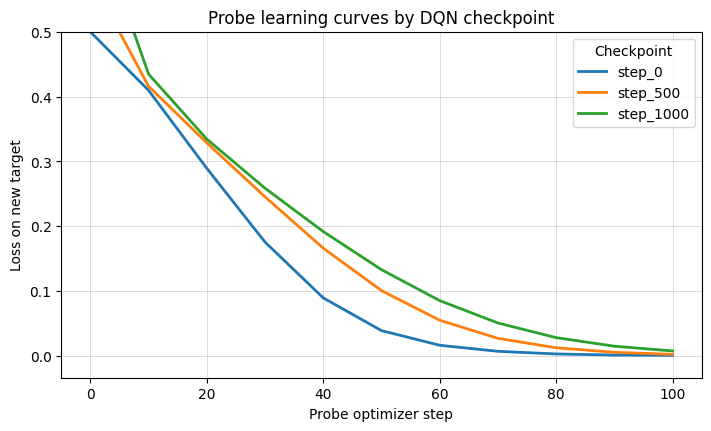

In [16]:
def plot_checkpoint_learning_curves(df, save_path=None):
    def checkpoint_sort_key(checkpoint):
        try:
            return int(str(checkpoint).split("_")[-1])
        except (TypeError, ValueError):
            return float("inf")

    grouped = (
        df.groupby(["checkpoint", "step"], as_index=False)["loss"]
        .mean()
        .sort_values(["checkpoint", "step"])
    )
    checkpoint_order = sorted(grouped["checkpoint"].unique(), key=checkpoint_sort_key)

    fig, ax = plt.subplots(figsize=(7.0, 4.2), constrained_layout=True)
    for checkpoint in checkpoint_order:
        group = grouped[grouped["checkpoint"] == checkpoint].sort_values("step")
        ax.plot(group["step"], group["loss"], linewidth=2.0, label=checkpoint)

    ax.set_title("Probe learning curves by DQN checkpoint")
    ax.set_xlabel("Probe optimizer step")
    ax.set_ylabel("Loss on new target")
    ax.grid(True, linewidth=0.6, alpha=0.5)
    ax.set_ylim(top=0.5)
    ax.legend(title="Checkpoint")

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved checkpoint curve figure to {save_path}")
    return fig


fig = plot_checkpoint_learning_curves(curves, save_path=FIGURES_DIR / "figure4_checkpoint_probe_curves.png")

## Paper-Scale Run (one variant per session)

Edit `architecture`/`environment` and the `tag` for this session's variant, then uncomment the last lines. Rough cost on a Colab T4: MLP ≈ 30–60 min, CNN several hours (the probe dominates: 4 checkpoints × 10 tasks × 2,000 steps = 80k probe-optimizer steps on top of 100k training steps). Download the CSV from `outputs/tables/` before the session ends; to compare variants, load their CSVs side by side and plot each with `plot_checkpoint_learning_curves`.

warmup:   0%|          | 0/2000 [00:00<?, ?step/s]

checkpoint saved @ step 0 (initialization)


train:   0%|          | 0/100000 [00:00<?, ?step/s]

checkpoint saved @ step 10000 (loss=0.0066)
checkpoint saved @ step 20000 (loss=0.0215)
checkpoint saved @ step 50000 (loss=0.0389)
checkpoint saved @ step 100000 (loss=0.0490)


probe step_0 [task 1/10]:   0%|          | 0/2000 [00:00<?, ?step/s]

...

probe step_100000 [task 9/10]:   0%|          | 0/2000 [00:00<?, ?step/s]

probe step_100000 [task 10/10]:   0%|          | 0/2000 [00:00<?, ?step/s]

Saved checkpoint probe curves to /kaggle/working/outputs/tables/figure4_curves_cnn_easy.csv
experiment finished in 136.3 min


,checkpoint,final_loss
0,step_0,0.000021
1,step_10000,0.000002
2,step_100000,0.067044
3,step_20000,0.002794
4,step_50000,0.010662


Saved checkpoint curve figure to /kaggle/working/outputs/figures/figure4_curves_cnn_easy.png


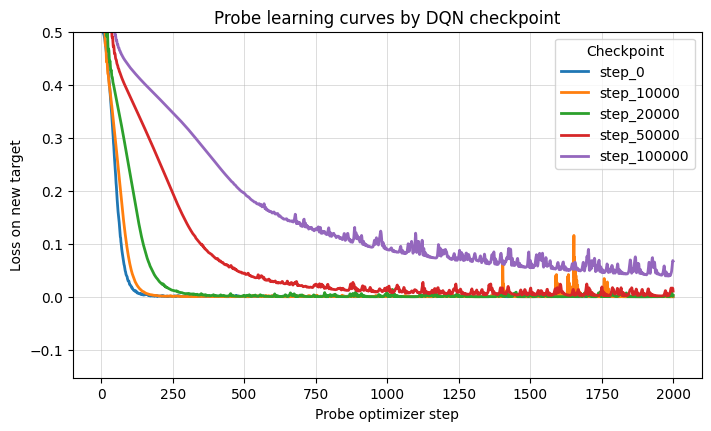

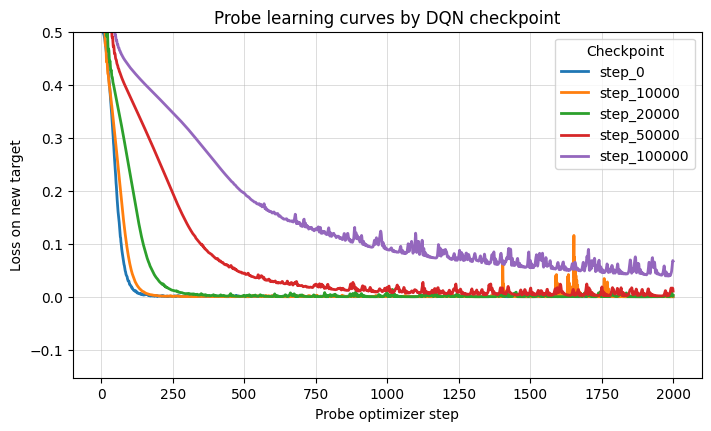

In [17]:
paper_cfg = make_paper_like_config(
    data_root=str(DATA_ROOT),
    architecture="cnn",     # EDIT: "mlp" or "cnn"
    environment="easy",     # EDIT: "easy", "hard", or "sparse"
)
tag = "cnn_easy"            # EDIT: used in the output filename

# Uncomment to launch:
paper_curves = run_checkpoint_curve_experiment(
    paper_cfg, save_path=TABLES_DIR / f"figure4_curves_{tag}.csv"
)
display(paper_curves.groupby("checkpoint", as_index=False)["final_loss"].mean())
plot_checkpoint_learning_curves(paper_curves, save_path=FIGURES_DIR / f"figure4_curves_{tag}.png")